# Joint distributions

*Prerequisite: [Records and Record Distributions](02_records.ipynb) and
[Distribution basics](01_distributions.ipynb).*

Every joint distribution in ProbPipe is a `RecordDistribution` — a
`Distribution` whose samples are `Record`s keyed by named
components. The shared `RecordDistribution` surface (`.fields`,
`dist[name]`, `dist.select_all()`, Record-shaped `sample` /
`log_prob` / `mean`, `condition_on` dropping components) is
introduced in the [records notebook §6–§9](02_records.ipynb). This
notebook focuses on the four concrete flavours, which differ in
*how* the joint is parameterised:

| Class | When to reach for it |
|---|---|
| `ProductDistribution` | Components are independent |
| `SequentialJointDistribution` | Component `k` depends on components `< k` |
| `JointGaussian` | Fully Gaussian joint; closed-form conditioning |
| `JointEmpirical` / `NumericJointEmpirical` | You already have joint samples (MCMC / importance) |

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (Normal, Gamma, MultivariateNormal,
                      ProductDistribution, SequentialJointDistribution,
                      JointGaussian, JointEmpirical, NumericJointEmpirical,
                      RecordDistribution, FlattenedDistributionView,
                      sample, log_prob, mean, variance, condition_on,
                      workflow_function)

## 1. `ProductDistribution`: independent components

`ProductDistribution` is the simplest joint: components are listed as keyword arguments and drawn independently. Its log-probability factorises as the sum of per-component log-probs — the property that distinguishes it from the other three flavours covered below.

In [2]:
joint = ProductDistribution(
    theta=Normal(loc=0.0, scale=1.0, name="theta"),
    sigma=Gamma(concentration=2.0, rate=1.0, name="sigma"),
)

# log_prob accepts either a Record or a plain dict with matching keys.
x = {"theta": jnp.array(0.5), "sigma": jnp.array(1.5)}
lp_joint = float(log_prob(joint, x))
lp_sum = float(log_prob(joint["theta"], x["theta"])) + float(log_prob(joint["sigma"], x["sigma"]))
print(f"joint log_prob:   {lp_joint:.4f}")
print(f"sum of marginals: {lp_sum:.4f}  (match: {bool(jnp.isclose(lp_joint, lp_sum))})")

joint log_prob:   -2.1385
sum of marginals: -2.1385  (match: True)


## 2. Views preserve correlation under broadcasting

Indexing a joint with a field name returns a view onto the parent — see [Records and Record Distributions §6](02_records.ipynb) for the view mechanics. The thing that matters specifically for joints: two views from the **same** parent stay correlated when both are passed to a `@workflow_function`. The sweep layer draws from the parent joint once per MC sample and extracts each component from that shared draw, so `f(**joint.select_all())` and `f(joint)` produce the same output.

In [3]:
@workflow_function
def scaled_diff(theta, sigma):
    return (theta - 1.0) / sigma

out = scaled_diff(**joint.select_all(), n_broadcast_samples=1_000)
print(f"mean of (theta - 1) / sigma ≈ {float(mean(out)):.3f}")
print(f"n draws:                     {out.n}")

mean of (theta - 1) / sigma ≈ -1.082
n draws:                     1000


## 3. `condition_on` drops components

Passing observed values for any subset of the `fields` returns a
new `RecordDistribution` over the **remaining** components. For
`ProductDistribution` the remaining marginals are unchanged; for
`JointGaussian` they get the closed-form posterior update; for the
sequential and empirical joints the semantics adapt
class-by-class.


In [4]:
conditioned = condition_on(joint, theta=jnp.array(2.0))
print("fields after condition_on(theta=2.0):", conditioned.fields)
print("sample:", sample(conditioned))


fields after condition_on(theta=2.0): ('sigma',)


sample: Record(sigma=Array(1.1162606, dtype=float32))


## 4. Multivariate and nested components

Each component can itself be multivariate — `event_shapes` reports
the per-component shape regardless. Components can also be nested
dict-of-dicts; the nesting is purely organisational (components
are still independent) but carries through into samples as nested
`Record`s.


event_shapes: {'pos': (2,), 'vel': (2,)}


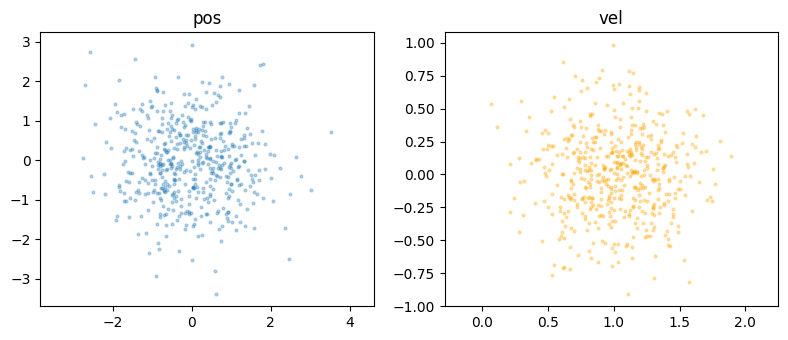

In [5]:
joint_mv = ProductDistribution(
    pos=MultivariateNormal(loc=jnp.zeros(2), cov=jnp.eye(2), name="pos"),
    vel=MultivariateNormal(loc=jnp.array([1.0, 0.0]), cov=0.1 * jnp.eye(2), name="vel"),
)
print("event_shapes:", joint_mv.event_shapes)

draws = sample(joint_mv, sample_shape=(500,))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.scatter(draws["pos"][:, 0], draws["pos"][:, 1], alpha=0.3, s=4)
ax1.set_title("pos"); ax1.axis("equal")
ax2.scatter(draws["vel"][:, 0], draws["vel"][:, 1], alpha=0.3, s=4, color="orange")
ax2.set_title("vel"); ax2.axis("equal")
plt.tight_layout(); plt.show()


A `ProductDistribution`'s components can themselves be nested dicts of distributions. The draw mirrors that nesting; access leaves with the usual nested-Record syntax (chained brackets or a tuple key):

In [6]:
nested = ProductDistribution(
    physics={
        "force": Normal(loc=0.0, scale=1.0, name="force"),
        "mass": Gamma(concentration=2.0, rate=1.0, name="mass"),
    },
    noise=Normal(loc=0.0, scale=0.1, name="noise"),
)
draw = sample(nested)
print("sample:", draw)
print("draw['physics']['force']:", float(draw["physics"]["force"]))
print("draw['physics', 'force']:", float(draw["physics", "force"]))


sample: Record(physics=Record(force=Array(0.96188295, dtype=float32), mass=Array(1.5061157, dtype=float32)), noise=Array(0.26262152, dtype=float32))
draw['physics']['force']: 0.9618829488754272
draw['physics', 'force']: 0.9618829488754272


## 5. `SequentialJointDistribution` — autoregressive components

When a component depends on earlier components, pass a callable
whose parameter names match the dependencies. Sampling evaluates
the callable on the already-drawn values; the `RecordDistribution`
surface is otherwise identical.


fields: ('theta', 'y')


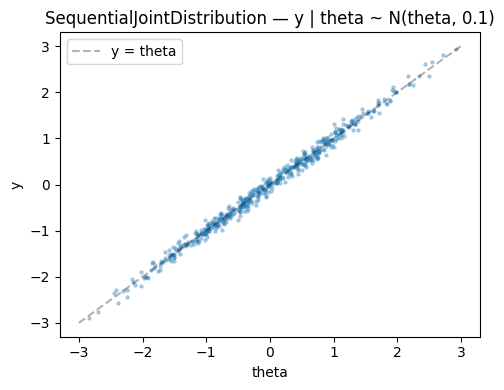

In [7]:
sjd = SequentialJointDistribution(
    theta=Normal(loc=0.0, scale=1.0, name="theta"),
    y=lambda theta: Normal(loc=theta, scale=0.1, name="y"),
)
print("fields:", sjd.fields)

draws = sample(sjd, sample_shape=(500,))
plt.figure(figsize=(5, 4))
plt.scatter(draws["theta"], draws["y"], alpha=0.3, s=5)
plt.plot([-3, 3], [-3, 3], "k--", alpha=0.3, label="y = theta")
plt.xlabel("theta"); plt.ylabel("y"); plt.legend()
plt.title("SequentialJointDistribution — y | theta ~ N(theta, 0.1)")
plt.tight_layout(); plt.show()


`condition_on` on an earlier component binds the callable to the
observed value; the result is still a `RecordDistribution` over
the remaining components.


In [8]:
posterior_like = condition_on(sjd, theta=jnp.array(1.5))
print("fields after condition_on(theta=1.5):", posterior_like.fields)
draws = sample(posterior_like, sample_shape=(5,))
print("y draws (all centred near theta=1.5):", draws)


fields after condition_on(theta=1.5): ('y',)


y draws (all centred near theta=1.5): NumericRecordArray(batch_shape=(5,), y=array(shape=(5,)))


## 6. `JointGaussian` — exact joint with closed-form conditioning

`JointGaussian` holds a single multivariate normal over the
concatenation of all components; per-component sizes are declared
as kwargs. The `RecordDistribution` API is unchanged — `sample`
returns a `Record`, `mean` / `variance` return `Record`s — but
`condition_on` runs the analytical Gaussian update instead of
falling back to MCMC.


In [9]:
jg = JointGaussian(
    mean=jnp.array([0.0, 1.0, -1.0, 2.0]),
    cov=jnp.array([[1.0, 0.5, 0.0, 0.2],
                   [0.5, 1.0, 0.3, 0.0],
                   [0.0, 0.3, 1.0, 0.0],
                   [0.2, 0.0, 0.0, 0.5]]),
    a=1, b=2, c=1,
)
print("fields:      ", jg.fields)
print("event_shapes:", jg.event_shapes)
print("mean:        ", mean(jg))

cond = condition_on(jg, a=jnp.array([0.5]))
print("\nafter condition_on(a=[0.5]):")
print("  fields:           ", cond.fields)
print("  mean (posterior): ", mean(cond))


fields:       ('a', 'b', 'c')
event_shapes: {'a': (1,), 'b': (2,), 'c': (1,)}
mean:         Record(a=array(shape=(1,)), b=array(shape=(2,)), c=array(shape=(1,)))



after condition_on(a=[0.5]):
  fields:            ('b', 'c')
  mean (posterior):  Record(b=array(shape=(2,)), c=array(shape=(1,)))


## 7. `JointEmpirical` — pre-drawn samples as a joint

When you already have correlated samples (MCMC draws, importance
samples, bootstrap replicates) wrap them as a `JointEmpirical`.
Re-sampling draws **joint rows**, not per-component marginals, so
every pairwise correlation in the sample set is preserved.
Conditioning uses nearest-neighbour resampling on the observed
field.

When every component is numeric, `JointEmpirical(...)` dispatches
to `NumericJointEmpirical`, which additionally exposes
`SupportsMean` and
`SupportsVariance`.


In [10]:
# Correlated samples from a latent AR(1): x_t = 0.6*x_{t-1} + eps
rng = np.random.default_rng(0)
n = 1000
x = np.zeros(n)
for t in range(1, n):
    x[t] = 0.6 * x[t - 1] + rng.normal() * 0.5
y = 0.5 * x + rng.normal(size=n) * 0.2

je = NumericJointEmpirical(x=jnp.asarray(x), y=jnp.asarray(y))
print("fields:  ", je.fields)
print("mean:    ", mean(je))
print("variance:", variance(je))


fields:   ('x', 'y')
mean:     Record(x=Array(-0.05983598, dtype=float32), y=Array(-0.03164241, dtype=float32))
variance: Record(x=Array(0.3741798, dtype=float32), y=Array(0.1427942, dtype=float32))


Joint-row resampling preserves the `x`–`y` correlation:


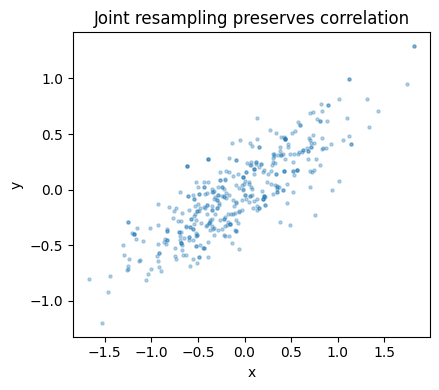

In [11]:
resampled = sample(je, sample_shape=(400,))
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(np.asarray(resampled["x"]), np.asarray(resampled["y"]), alpha=0.3, s=5)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Joint resampling preserves correlation")
plt.tight_layout(); plt.show()


Conditioning on a value picks rows whose `x` is near the target
and returns the corresponding conditional `RecordDistribution`
over the remaining fields.


In [12]:
cond = condition_on(je, x=jnp.array(1.0))
print("fields after condition_on(x=1.0):", cond.fields)
y_cond = sample(cond, sample_shape=(200,))
print("E[y | x=1.0] ≈", float(jnp.mean(y_cond["y"])), "(expect ≈ 0.5)")


fields after condition_on(x=1.0): ('y',)


E[y | x=1.0] ≈ -0.01989496499300003 (expect ≈ 0.5)


## 8. `FlattenedDistributionView` — a flat-array door onto any `RecordDistribution`

Optimisers, MCMC samplers, and neural nets often want a single flat
vector, not a named `Record`. `FlattenedDistributionView(dist)` wraps any
`RecordDistribution` as an ordinary `Distribution` with
`event_shape=(flat_size,)` — internally it flattens the `Record`
on the way out and unflattens on the way in to `log_prob`.
Components are concatenated in field-insertion order (the same order
as `.fields`).

In [13]:
flat = FlattenedDistributionView(joint)  # joint from section 1
print("event_shape:", flat.event_shape, "(sigma scalar + theta scalar = 2)")
print("fields (insertion flattening order):", joint.fields)

flat_draw = sample(flat)
print("\nflat sample:    ", flat_draw)
print("unflatten_value:", joint.unflatten_value(flat_draw))

# log_prob agrees in either form, as long as the flat vector uses
# the same field-insertion order.
x_record = {"sigma": 1.5, "theta": 0.5}
x_flat = jnp.array([float(x_record[f]) for f in joint.fields])
print("\nlog_prob(joint, record):", float(log_prob(joint, x_record)))
print("log_prob(flat,  vector):", float(log_prob(flat, x_flat)))


event_shape: (2,) (sigma scalar + theta scalar = 2)
fields (insertion flattening order): ('theta', 'sigma')



flat sample:     NumericRecord(sample=array(shape=(2,)))
unflatten_value: NumericRecord(theta=Array(1.1140472, dtype=float32), sigma=Array(3.0314841, dtype=float32))

log_prob(joint, record): -2.1384735107421875
log_prob(flat,  vector): -2.1384735107421875


## Summary

Every joint distribution in ProbPipe is a `RecordDistribution`.
That means:

- Samples, moments, and log-prob inputs are named `Record`s keyed
  by `.fields`.
- `dist[name]` returns a `_RecordDistributionView` — a lightweight
  component reference whose parent identity drives correlation
  preservation when you splat `dist.select_all()` into a
  `@workflow_function`.
- `condition_on` drops observed components and returns a smaller
  `RecordDistribution` of the same flavour.
- `FlattenedDistributionView` adapts the whole thing to flat-vector APIs when
  you need one.

Pick the concrete class by how the joint is parameterised:

- Independent components → `ProductDistribution`.
- Autoregressive dependence → `SequentialJointDistribution`.
- Fully Gaussian with exact conditioning → `JointGaussian`.
- Pre-drawn samples → `JointEmpirical` / `NumericJointEmpirical`.

Downstream code that touches only the shared `RecordDistribution`
surface stays the same across all four.
